<a href="https://colab.research.google.com/github/Erica97/Erica97.github.io/blob/master/Vandalism_in_Wikipedia_edits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
    <h1>Using Classification and Regression Trees (CART) and Random Forest to identify Vandalism in Wikipedia</h1>
    <hr>
    <h3>Erica Li</h3>
    <h3>September 22, 2019</h3>
</center>


# Project background
Wikipedia is the world’s largest free online encyclopedia, containing in the neighbourhood of 5.8 million articles with roughly 156,000 edits per day. Wikipedia allows anyone to contribute/edit entries, which promotes rapid content creation and community-based error checking. An unfortunate side effect of this approach is the presence of vandalism. Specifically, we refer to pages that have had information removed, incorrect information added, or the presence of inappropriate content. Due to the volume of entries being changed on a daily basis, it is incredibly diffcult to manually (i.e., human checking) ensure the accuracy of pages and remove any instances of vandalism.

The goal of the project is to investigate vandalism in Wikipedia (en.wikipedia.org). We will look at a dataset that summarizes the revision history for the “Language” entry on Wikipedia (en.wikipedia.org/wiki/Language) and conduct some exploratory data analysis (EDA) and look into predicting whether a particular revision was an instance of vandalism or not. 


In [0]:
# Import packages
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv('https://docs.google.com/uc?export=download&id=1la-cSzyr8RjehjLv-g4g7KGaQmJWRCc2') 
df.head() # prints the first 5 rows of the dataframe 

,Vandal,Minor,LoggedIn,HTTP,NumWordsAdded,NumWordsRemoved
0,0,1,1,1,96,0
1,0,1,1,0,3,1
2,0,0,1,0,0,4
3,0,1,0,0,10,92
4,0,1,1,1,94,10


The table below contains the data dictionary.

|Feature          |Definition                                             |
|:---------------:|:------------------------------------------------------|
|Vandal           |1 if the edit was vandalism, 0 if not                  |
|Minor            |1 if the edit was marked as a minor edit, 0 if not     |    
|LoggedIn         |1 if the user made edit from Wiki account, 0 if not    |
|HTTP             |1 if edit contained web address, 0 if not              | 
|NumWordsAdded    |Number of unique words added                           |
|NumWordsRemoved  |Number of unique words removed                         |


## Exploratory data analysis
Prior to using CART and random forests to make predictions, we start with EDA to get a better feel for the Wikipedia dataset we are using. We will examine if there are any non-numeric variables, then drop all the missing values.

In [0]:
# df_digit_indicator is calculated below to get you started. 
df_digit_indicator = df.applymap(lambda x: x.isdigit())  

number_non_digits = (df_digit_indicator==0).sum()

print('There are non-numerical values as follows \n{} '.format(number_non_digits))



There are non-numerical values as follows 
Vandal             2
Minor              1
LoggedIn           2
HTTP               1
NumWordsAdded      2
NumWordsRemoved    1
dtype: int64 


In [0]:
for col in df.columns:
  print(df[col][df_digit_indicator[col] == False].value_counts())


ERROR    2
Name: Vandal, dtype: int64
ERROR    1
Name: Minor, dtype: int64
ERROR    2
Name: LoggedIn, dtype: int64
ERROR    1
Name: HTTP, dtype: int64
ERROR    2
Name: NumWordsAdded, dtype: int64
ERROR    1
Name: NumWordsRemoved, dtype: int64


In [0]:
# drop missing values
df = df.replace('ERROR', np.nan)
df = df.dropna()

# convert non-numeric values to numeric 

df = df.apply(pd.to_numeric, errors='coerce')

In [0]:
# count number of instances after data cleansing

number_of_edits = len(df)
print('There are {} edits considered.'.format(number_of_edits))

There are 3867 edits considered.


In [0]:
# % of instances identified as vandalism

percent_vandal = df['Vandal'].mean()*100
print('{:.2f}% of the edits were vandalism.'.format(percent_vandal))

46.75% of the edits were vandalism.


## Preperation for model training
Randomly split data clean into a training set and test set, named data train and data test, respectively. We will place 70% of the data into the training set and the remainder in the test set.

In [0]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Vandal',1), df['Vandal'], test_size=0.30, random_state=5)


In [0]:
# count instances in the training dataset

len(y_train)


2706

In [0]:
# count instances of confirmed vandalized edits

sum(y_train)



1257

# Using CART and RF with sklearn

In this section, we will use CART and Random Forest to classify target variables (e.g., Wikipedia edit is or is not vandelized).
## CART Model


The score of this model over training data is 0.730 and 0.717 over the testing data


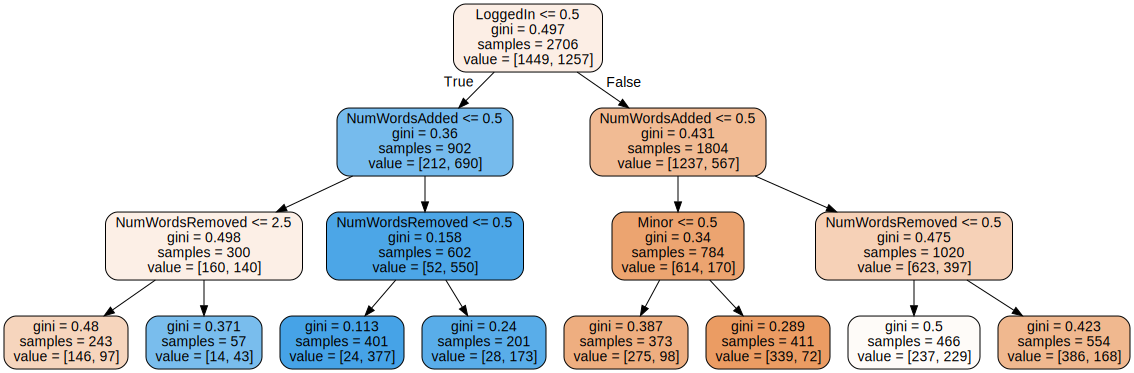

In [0]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from subprocess import call
from IPython.display import SVG
from graphviz import Source

# Train the CART model
cart_model = DecisionTreeClassifier(random_state=3,max_depth=3)
cart_model.fit(x_train, y_train)
train_score = cart_model.score(x_train, y_train)
test_score = cart_model.score(x_test, y_test)

# Print out summary of model performance 
print('The score of this model over training data is {:.3f} and {:.3f} over the testing data'.format(train_score, test_score))

# Visualize the decision tree
cart_graph = Source(export_graphviz(cart_model,
                   feature_names = df.columns[1:],
                   rounded = True, proportion = False, 
                  filled = True))
SVG(cart_graph.pipe(format='svg'))

In [0]:
# count number of nodes in the tree above

cart_model.tree_.node_count


15

In [0]:
# find the most significant features

pd.Series(cart_model.feature_importances_, index=x_train.columns)


Minor              0.007789
LoggedIn           0.634670
HTTP               0.000000
NumWordsAdded      0.276306
NumWordsRemoved    0.081235
dtype: float64

In [0]:
# assess the accuracy of the decision tree

cart_model.fit(x_test, y_test)
mdlAcc = np.mean((cart_model.predict(x_test) == y_test))
print('The accuracy of this model on the training data is {:.3f}'.format(round(mdlAcc,3)))


The accuracy of this model on the training data is 0.721


When the maximum depth of a decision tree increases, the training data accuracy increases significantly and lead to **overfitting**.

In [0]:
# let the maximum depth = 10

cart_model = DecisionTreeClassifier(random_state=0,max_depth=10)

# a function to fit and score a model

def fit_and_score_model(mdl, x_train, x_test, y_train, y_test, random_state=0):
    
  
    # Fit an arbitrary model
    mdl.fit(x_train, y_train)
    
    # Calculate the score of the model on training and testing data
    train_score = mdl.score(x_train, y_train)
    test_score = mdl.score(x_test, y_test)
  
    # Print scores to terminal
    print('the accuracy on the: \n\t training data is {}'.format(round(train_score,3)))
    print('\t testing data is {}'.format(round(test_score, 3)))
    
    return train_score, test_score
  
# call the function fit_and_score_model
train_score, test_score = fit_and_score_model(cart_model, x_train, x_test, y_train, y_test)

the accuracy on the: 
	 training data is 0.773
	 testing data is 0.721


## Random Forest Model

As we discovered in the previous sections, individual CART trees can tend to overfit the data. To reduce this effect and improve subsequent model performance, we can combine the results of many decision trees in a random forest.

Use the ```RandomForestClassifier``` function from ```sklearn.ensemble``` to create a random forest model. This function combines classification trees by default (as required) and selects a subset of the feature variables to use in each bagged sample, as required by the random forest algorithm. Set the size of each bagged sample to 0.2, which coresponds to one fifth the size of the training data, using _max_ _features_ pramater and the _n_estimators_ parameter to 50. 

Experiment with _max_depth_ parameter of ```RandomForestClassifier``` $\in$ {2, 3, 4, 5, 6, 7} and measure the accuracy on the testing set. Turns out that **when the maximum depth is 5 the accuracy of the testing data set is maximized: 73.7%.**

In [0]:
from sklearn.ensemble import RandomForestClassifier


depths = [2, 3, 4, 5, 6, 7]
accuracy = pd.Series(index=depths)

for max_depth in depths:

    # Initialize the model
    rf_baseline_model = RandomForestClassifier(
        random_state = 0, 
        max_depth = max_depth,
        n_estimators = 50, max_features = 0.2
    )
    
    # Fit and train model
    print('For {} max_depth '.format(max_depth), end='')
    train_score, test_score = fit_and_score_model(rf_baseline_model, x_train, x_test, y_train, y_test)
    
    # Save model performance to dataframe
    cheat_scores.loc[max_depth] = test_score
    
print('\n***Best model has a score of {:.3f} with a max_depth of {}***'.format(cheat_scores.max(), cheat_scores.idxmax()))



For 2 max_depth the accuracy on the: 
	 training data is 0.72
	 testing data is 0.72
For 3 max_depth the accuracy on the: 
	 training data is 0.721
	 testing data is 0.722
For 4 max_depth the accuracy on the: 
	 training data is 0.741
	 testing data is 0.722
For 5 max_depth the accuracy on the: 
	 training data is 0.753
	 testing data is 0.737
For 6 max_depth the accuracy on the: 
	 training data is 0.758
	 testing data is 0.735
For 7 max_depth the accuracy on the: 
	 training data is 0.759
	 testing data is 0.734

***Best model has a score of 0.737 with a max_depth of 5***


# Cross-validation

Now that we can code the CART (DecisionTreeClassifier) and random forests (RandomForestClassifier) it's time to learn about how to adjust paramters to improve model performance. In this section, we'll focus exclusively on the RF, but the methods generalize to other models (e.g., linear regression, CART, deep learning). In the Random Forest section we chose an appropriate value for the n_estimators paramter by evaluating the model on the test data (i.e., x_test and y_test), however, this is cheating because we are using the test set to help decide the maximum depth of the random forest. If we use the test set to help tune our model then the model has "seen" the test data so we can no longer offer guarentees about how well **generalizes to unseen data**. 

Using cross-validation, we can choose parameters that generalize to unseen data and help limit over fitting. Cross-validation is a multi-round process. In each round, the the full training set is split into two subsets (1) a subset that the model is trained on, and (2) a subset that the model is evaluated on. After the rounds are complete, an aggregate measure of plan performance (e.g., average score) will be an estimate of the models performance. 

Now, lets use cross-validation to choose the _max_depth_ parameter in our RF model. We will use _cross_validate_ from sklearn to make the approriate data splits, and we'll take the model with the highest average score.

In [0]:
from sklearn.model_selection import cross_validate

# Initailize cross validation score DataFrame
depth_lb = 1
depth_ub = 21
cv_scores = pd.Series(index=np.arange(depth_lb, depth_ub))

for max_depth in range(depth_lb, depth_ub):
  
  # Initialize the model
  rf_cv1_model = RandomForestClassifier(random_state = 0, max_depth = max_depth,
                          n_estimators = 50, max_features = 0.2)

  # Run cross validation to get measure of out-of-sample error
  example_cv_results = cross_validate(rf_cv1_model, x_train, y_train, cv=5)
  
  # Record the average out-of-sample error
  cv_scores.loc[max_depth] = example_cv_results['test_score'].mean()

5

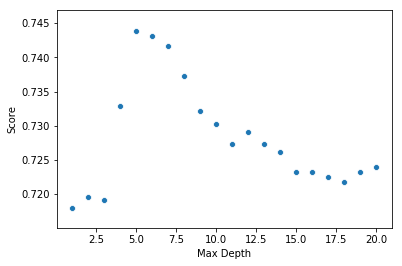

In [0]:


sns.scatterplot(x=cv_scores.index, y=cv_scores.values)
plt.xlabel('Max Depth')
plt.ylabel('Score')

cv_scores.idxmax()
# Max depth of 5 was chosen both times.


Base on the graph above, the highest score is achived when the maximum depth is at **5**. This confirms with the previous max depth parameter that we chose manually. 